# 3 · Inside the immutable evaluator

The evaluator is the contract. This chapter opens it up:

* the **official score** and why it is worst-group + a macro tie-breaker,
* the **fingerprint** the loop uses to prove the evaluator wasn't tampered with,
* the diagnostics it returns (per-slice accuracy, confusion matrix) that *inform*
  the agent but never feed the scalar score.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # make `harness` importable
import matplotlib
matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    print("building a small bdd-tiny ...")
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA)

dataset: ../data/bdd-tiny.lance


In [2]:
from harness.config import load_config
from harness.train import train
from harness.evaluator import evaluate, evaluator_fingerprint, MACRO_WEIGHT
model = train(load_config("base"), DATA)
res = evaluate(model, DATA)
print("score formula: worst_group + %.2f * macro" % MACRO_WEIGHT)
print("  %.4f = %.4f + %.2f * %.4f" % (res["score"], res["worst_group"], MACRO_WEIGHT, res["macro_accuracy"]))

score formula: worst_group + 0.25 * macro
  0.8835 = 0.6444 + 0.25 * 0.9562


### The tamper-proof fingerprint

In [3]:
fp = evaluator_fingerprint()
print("evaluator sha256:", fp)
# the loop records this every iteration; if evaluator.py changes, the hash changes
assert fp == evaluator_fingerprint()
print("stable across calls:", True)

evaluator sha256: 9983898e34e9cf37a82737d73b1675874166bbb6ef9c530ac36305384b540515
stable across calls: True


### Confusion matrix — *which* mistakes is the model making?

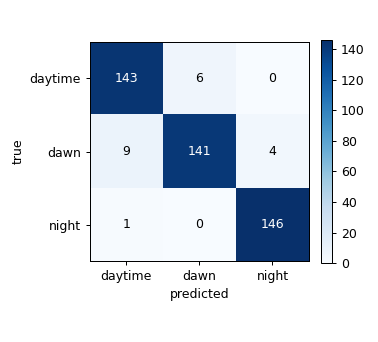

In [4]:
import numpy as np
cm = np.array(res["confusion"]); names = list(class_names())
fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(names); ax.set_yticks(range(3)); ax.set_yticklabels(names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
fig.colorbar(im, fraction=0.046); fig.tight_layout(); fig.savefig("fig_03_cm.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_03_cm.png")

**The rule.** `evaluator.py` and `data.py` are in the *immutable set*. The agent
may read these diagnostics to form a hypothesis, but the moment training code
reads the `test` split — or anything edits the evaluator — the run is void. The
loop enforces this with the fingerprint above (Chapter 6).